<a href="https://colab.research.google.com/github/seungah-lab/Intelligence-powered-epidemiology/blob/main/Week_4_%EB%8B%A4%ED%95%AD%ED%9A%8C%EA%B7%80_%EB%AA%A8%ED%98%95_quadratic_polynomial_ex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 다항회귀 모형 만들어보기 - PSA와 전립선암의 연관성이 더 복잡하다면

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
# 1. 데이터 준비 (앞선 단계의 전립선암 df 활용)

# 1. 데이터 로드
df = pd.read_csv("https://web.stanford.edu/~hastie/ElemStatLearn/datasets/prostate.data", sep='\t', index_col=0)

# 2. 데이터 구조 확인
print("--- Data Info ---")
print(df.head())

# 2.5 파생 변수 생성 (Feature Engineering)
# 조건: age > 70 이고 lbph > -1.38629436 인 경우 cancer_status = 1, 아니면 0
# lbph 수치 -1.386...은 실제 값으로 약 0.25에 해당함.

def define_cancer_status(row):
    if row['age'] > 70 and row['lbph'] > -1.38629436:
        return 1
    else:
        return 0

# 새로운 열 'cancer_status' 추가
df['cancer_status'] = df.apply(define_cancer_status, axis=1)

# 생성된 클래스의 분포 확인 (Class Imbalance 체크)
print("--- Class Distribution ---")
print(df['cancer_status'].value_counts())

print(df.head())

x = df['lpsa'].values.reshape(-1, 1)   # 1차원 벡터를 열이 1개인 2차원 행렬로 변환
y = df['cancer_status'].values

--- Data Info ---
     lcavol   lweight  age      lbph  svi       lcp  gleason  pgg45      lpsa  \
1 -0.579818  2.769459   50 -1.386294    0 -1.386294        6      0 -0.430783   
2 -0.994252  3.319626   58 -1.386294    0 -1.386294        6      0 -0.162519   
3 -0.510826  2.691243   74 -1.386294    0 -1.386294        7     20 -0.162519   
4 -1.203973  3.282789   58 -1.386294    0 -1.386294        6      0 -0.162519   
5  0.751416  3.432373   62 -1.386294    0 -1.386294        6      0  0.371564   

  train  
1     T  
2     T  
3     T  
4     T  
5     T  
--- Class Distribution ---
cancer_status
0    86
1    11
Name: count, dtype: int64
     lcavol   lweight  age      lbph  svi       lcp  gleason  pgg45      lpsa  \
1 -0.579818  2.769459   50 -1.386294    0 -1.386294        6      0 -0.430783   
2 -0.994252  3.319626   58 -1.386294    0 -1.386294        6      0 -0.162519   
3 -0.510826  2.691243   74 -1.386294    0 -1.386294        7     20 -0.162519   
4 -1.203973  3.282789   58 -

In [5]:
# 2. 다항 특성 생성 (3차 다항식: x, x^2, x^3)
poly = PolynomialFeatures(degree=3, include_bias=False)
x_poly = poly.fit_transform(x)

# 3. 모델 구성 및 학습 (입력 차원이 3으로 확장됨)
model_poly = Sequential([
    Dense(1, input_dim=3, activation='sigmoid')
])
model_poly.compile(optimizer='adam', loss='binary_crossentropy')
model_poly.fit(x_poly, y, epochs=500, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##### 4. 시각화

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


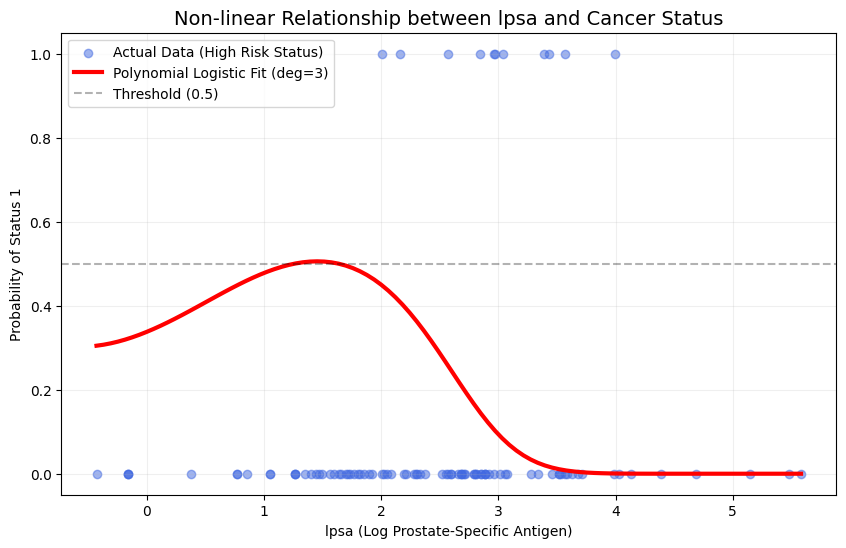

In [8]:
plt.figure(figsize=(10, 6))

# 1. 실제 데이터 산점도 (파란 점)
plt.scatter(x, y, alpha=0.5, color='royalblue', label='Actual Data (High Risk Status)')

# 2. 부드러운 Fitting Line을 위한 가상의 x축 데이터 생성
# 데이터의 최소값부터 최대값까지 100개의 지점을 만듭니다.
x_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)

# 3. 다항 특성 변환 (학습 때와 동일한 degree=3 적용)
# poly는 앞선 코드에서 정의한 PolynomialFeatures 객체입니다.
x_range_poly = poly.transform(x_range)

# 4. 모델로부터 예측 확률값(Probabilities) 추출
y_prob = model_poly.predict(x_range_poly)

# 5. 빨간색 Fitting Line 그리기
plt.plot(x_range, y_prob, color='red', linewidth=3, label='Polynomial Logistic Fit (deg=3)')

# 6. 임계치(Decision Boundary) 표시
plt.axhline(0.5, color='black', linestyle='--', alpha=0.3, label='Threshold (0.5)')

plt.title('Non-linear Relationship between lpsa and Cancer Status', fontsize=14)
plt.xlabel('lpsa (Log Prostate-Specific Antigen)')
plt.ylabel('Probability of Status 1')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()